In [28]:
# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

project_dir = Path("/mnt/eo/EO4Backcasting")

als_dir = project_dir / "_data" / "ALS_Wanda"

# IMPORTANT: set this to your continuous probability raster
continuous_prob_raster = (
    project_dir /
    "_predictions/predictions_global_model" /
    "global_model_no_dist_gt08_4conn_5ha_TRUE_0_1.tif"
)

genus_raster = (
    project_dir /
    "_data_aligned" /
    "genus_map_europe_aligned_to_probability_30m.tif"
)

biome_raster = (
    project_dir /
    "_data" /
    "ecoregions" /
    "ecoregions_boreal_temperate_mediterranean_aligned.tif"
)

analysis_cache_dir = project_dir / "_analysis_cache"
analysis_cache_dir.mkdir(parents=True, exist_ok=True)

fig_dir = project_dir / "_figures" / "ALS_height_probability_bins"
fig_dir.mkdir(parents=True, exist_ok=True)

out_csv = (
    analysis_cache_dir /
    "ALS_height_samples_continuous_probability_custom_bins_all_valid_locations_with_genus_biome.csv"
)

# ------------------------------------------------------------
# Sampling settings
# ------------------------------------------------------------

RANDOM_SEED = 42

# None = use all valid locations per ALS tile
MAX_POINTS_PER_TILE = None

# Do not sample ALS height values above 50 m
MIN_HEIGHT = 0
MAX_HEIGHT = 50

FORCE_RESAMPLE = True

In [29]:
# ------------------------------------------------------------
# Check files
# ------------------------------------------------------------

required_files = [
    prob_bin_raster,
    genus_raster,
    biome_raster,
]

for fp in required_files:
    if not Path(fp).exists():
        raise FileNotFoundError(fp)

als_files = sorted(
    list(als_dir.rglob("*.tif")) +
    list(als_dir.rglob("*.tiff"))
)

print("ALS files found:", len(als_files))
print("Probability-bin raster:", prob_bin_raster)
print("Genus raster:", genus_raster)
print("Biome raster:", biome_raster)

if len(als_files) == 0:
    raise FileNotFoundError(f"No ALS GeoTIFF files found in {als_dir}")

ALS files found: 3310
Probability-bin raster: /mnt/eo/EO4Backcasting/_predictions/probability_bins_5classes.tif
Genus raster: /mnt/eo/EO4Backcasting/_data_aligned/genus_map_europe_aligned_to_probability_30m.tif
Biome raster: /mnt/eo/EO4Backcasting/_data/ecoregions/ecoregions_boreal_temperate_mediterranean_aligned.tif


In [30]:
# ------------------------------------------------------------
# Inspect probability-bin raster
# ------------------------------------------------------------

with rasterio.open(prob_bin_raster) as src:
    print("CRS:", src.crs)
    print("Shape:", src.height, src.width)
    print("Resolution:", src.res)
    print("Nodata:", src.nodata)
    print("Bounds:", src.bounds)

    # Read a small sample for quick value check
    sample = src.read(1, out_shape=(1, max(1, src.height // 100), max(1, src.width // 100)))
    vals = np.unique(sample[np.isfinite(sample)])
    print("Unique values in coarse sample:", vals[:30])

CRS: EPSG:3035
Shape: 140000 130000
Resolution: (30.0, 30.0)
Nodata: 0.0
Bounds: BoundingBox(left=2612197.933345846, bottom=1365550.4228236396, right=6512197.933345846, top=5565550.42282364)
Unique values in coarse sample: [0 1 2 3 4 5]


In [31]:
# ------------------------------------------------------------
# Lookup tables
# Adjust if your raster coding differs
# ------------------------------------------------------------

# Assumption: probability_bins_5classes.tif uses integer classes 1-5.
# If your raster uses 0-4, change this dictionary accordingly.
prob_bin_lookup = {
    1: "0.00–0.25",
    2: "0.25–0.50",
    3: "0.50–0.75",
    4: "0.75–0.90",
    5: "0.90–1.00",
}

prob_bin_order = [
    "0.00–0.25",
    "0.25–0.50",
    "0.50–0.75",
    "0.75–0.90",
    "0.90–1.00",
]

genus_lookup = {
    0: "Larix",
    1: "Picea",
    2: "Pinus",
    3: "Fagus",
    4: "Quercus",
    5: "Other needleleaf",
    6: "Other broadleaf",
    7: "No trees",
}

biome_lookup = {
    1: "Boreal",
    2: "Temperate",
    3: "Mediterranean",
}

In [32]:
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def safe_window_from_bounds(bounds, ref_src):
    """
    Create a rasterio window from bounds and clip it to raster extent.
    """
    try:
        window = from_bounds(*bounds, transform=ref_src.transform)
        window = window.round_offsets().round_lengths()

        full_window = rasterio.windows.Window(
            col_off=0,
            row_off=0,
            width=ref_src.width,
            height=ref_src.height
        )

        window = window.intersection(full_window)

        if window.width <= 0 or window.height <= 0:
            return None

        return window

    except Exception:
        return None


def get_raster_bounds_in_target_crs(raster_path, target_crs):
    """
    Transform raster bounds to target CRS.
    """
    raster_path = Path(raster_path)

    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster has no CRS: {raster_path}")

        bounds_target = transform_bounds(
            src.crs,
            target_crs,
            *src.bounds,
            densify_pts=21
        )

    return bounds_target


def pixel_centres_from_window_rows_cols(src, window, rows, cols):
    """
    Convert row/col positions within a raster window to map coordinates.
    """
    abs_rows = rows + int(window.row_off)
    abs_cols = cols + int(window.col_off)

    xs, ys = rasterio.transform.xy(
        src.transform,
        abs_rows,
        abs_cols,
        offset="center"
    )

    return np.asarray(xs), np.asarray(ys)


def sample_raster_values(raster_path, xs, ys, input_crs, band=1):
    """
    Sample raster values at x/y coordinates.

    Parameters
    ----------
    raster_path : path-like
        Raster to sample.
    xs, ys : array-like
        Coordinates in input_crs.
    input_crs : rasterio CRS
        CRS of the input coordinates.
    band : int
        Raster band to sample.
    """
    raster_path = Path(raster_path)

    with rasterio.open(raster_path) as src:
        if src.crs != input_crs:
            transformer = Transformer.from_crs(input_crs, src.crs, always_xy=True)
            xs_t, ys_t = transformer.transform(xs, ys)
            coords = list(zip(xs_t, ys_t))
        else:
            coords = list(zip(xs, ys))

        vals = np.array(
            [v[0] for v in src.sample(coords, indexes=band)],
            dtype="float64"
        )

        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan

        # Common invalid nodata convention
        vals[vals <= -9990] = np.nan

    return vals


def clean_code_array(vals):
    """
    Convert sampled categorical raster values to nullable integer codes.
    """
    out = pd.Series(vals)
    out = out.round()
    out = out.astype("Int64")
    return out


def select_sample_indices(valid_idx, sample_fraction=None, max_points=None, rng=None):
    """
    Select sample indices from valid pixels.

    If sample_fraction is None, all valid pixels are used.
    If sample_fraction is given, this fraction of valid pixels is sampled.
    max_points can still be used as an upper cap.
    """
    valid_idx = np.asarray(valid_idx)
    n_valid = len(valid_idx)

    if n_valid == 0:
        return valid_idx

    # Use all valid locations
    if sample_fraction is None:
        sample_idx = valid_idx

    # Use a random fraction of valid locations
    else:
        if rng is None:
            rng = np.random.default_rng(42)

        n_sample = int(np.floor(n_valid * sample_fraction))
        n_sample = max(n_sample, 1)

        sample_idx = rng.choice(
            valid_idx,
            size=n_sample,
            replace=False
        )

    # Optional upper cap
    if max_points is not None and len(sample_idx) > max_points:
        if rng is None:
            rng = np.random.default_rng(42)

        sample_idx = rng.choice(
            sample_idx,
            size=max_points,
            replace=False
        )

    return sample_idx

def classify_continuous_probability(prob_vals):
    """
    Classify continuous probabilities into custom bins.

    Internal bins:
    1: 0.00–0.25
    2: 0.25–0.50
    3: 0.50–0.70
    4: 0.70–0.80
    5: >0.80

    Plot labels are kept in the old 0.25-style scheme for visual consistency.
    """
    prob_vals = np.asarray(prob_vals, dtype="float64")

    codes = np.full(prob_vals.shape, np.nan)

    codes[(prob_vals >= 0.00) & (prob_vals < 0.25)] = 1
    codes[(prob_vals >= 0.25) & (prob_vals < 0.50)] = 2
    codes[(prob_vals >= 0.50) & (prob_vals < 0.70)] = 3
    codes[(prob_vals >= 0.70) & (prob_vals < 0.80)] = 4
    codes[(prob_vals >= 0.80) & (prob_vals <= 1.00)] = 5

    return codes


prob_bin_lookup_internal = {
    1: "0.00–0.25",
    2: "0.25–0.50",
    3: "0.50–0.70",
    4: "0.70–0.80",
    5: ">0.80",
}

# Plot labels only; these are not the exact internal bin limits.
prob_bin_lookup_plot = {
    1: "0.00–0.25",
    2: "0.25–0.50",
    3: "0.50–0.75",
    4: "0.75–0.90",
    5: "0.90–1.00",
}

prob_bin_order_plot = [
    "0.00–0.25",
    "0.25–0.50",
    "0.50–0.75",
    "0.75–0.90",
    "0.90–1.00",
]

In [33]:
# ------------------------------------------------------------
# Main sampling workflow
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)

if out_csv.exists() and not FORCE_RESAMPLE:
    df_samples = pd.read_csv(out_csv)
    print("Loaded cached samples:", out_csv)

else:
    all_samples = []

    with rasterio.open(continuous_prob_raster) as prob_src:
        prob_crs = prob_src.crs
        prob_nodata = prob_src.nodata

        print("Continuous probability raster CRS:", prob_crs)
        print("Continuous probability raster shape:", prob_src.height, prob_src.width)
        print("Continuous probability raster nodata:", prob_nodata)

        for i, als_fp in enumerate(als_files, start=1):
            als_fp = Path(als_fp)
            print(f"\n[{i}/{len(als_files)}] {als_fp.name}")

            try:
                als_bounds_prob_crs = get_raster_bounds_in_target_crs(
                    als_fp,
                    prob_crs
                )

                win = safe_window_from_bounds(
                    als_bounds_prob_crs,
                    prob_src
                )

                if win is None:
                    print("  No overlap with probability raster. Skipped.")
                    continue

                prob_arr = prob_src.read(1, window=win).astype("float64")

                valid_prob = np.isfinite(prob_arr)

                if prob_nodata is not None:
                    valid_prob &= prob_arr != prob_nodata

                # If your probability raster is stored as 0–100 instead of 0–1,
                # this rescales it automatically.
                max_prob_in_window = np.nanmax(prob_arr[valid_prob]) if valid_prob.any() else np.nan

                if np.isfinite(max_prob_in_window) and max_prob_in_window > 1.5:
                    prob_arr = prob_arr / 100.0

                valid_prob &= prob_arr >= 0
                valid_prob &= prob_arr <= 1

                rows, cols = np.where(valid_prob)
                n_candidate = len(rows)

                if n_candidate == 0:
                    print("  No valid probability pixels inside ALS tile. Skipped.")
                    continue

                prob_vals = prob_arr[rows, cols]
                prob_codes = classify_continuous_probability(prob_vals)

                valid_class = np.isfinite(prob_codes)

                if valid_class.sum() == 0:
                    print("  No probability pixels assigned to classes. Skipped.")
                    continue

                rows = rows[valid_class]
                cols = cols[valid_class]
                prob_vals = prob_vals[valid_class]
                prob_codes = prob_codes[valid_class]

                print("  Candidate probability pixels:", len(rows))
                print("  Probability class counts:")
                print(pd.Series(prob_codes).value_counts().sort_index().to_dict())

                xs, ys = pixel_centres_from_window_rows_cols(
                    prob_src,
                    win,
                    rows,
                    cols
                )

                height_vals = sample_raster_values(
                    raster_path=als_fp,
                    xs=xs,
                    ys=ys,
                    input_crs=prob_crs,
                    band=1
                )

                valid_height = (
                    np.isfinite(height_vals) &
                    (height_vals >= MIN_HEIGHT) &
                    (height_vals <= MAX_HEIGHT)
                )

                valid_idx = np.where(valid_height)[0]
                n_valid = len(valid_idx)

                if n_valid == 0:
                    print("  No valid ALS heights <= 50 m at probability pixels. Skipped.")
                    continue

                sample_idx = select_sample_indices(
                    valid_idx=valid_idx,
                    sample_fraction=None,             # None = use all valid locations
                    max_points=MAX_POINTS_PER_TILE,   # None = no cap
                    rng=rng
                )

                n_sample = len(sample_idx)

                xs_s = xs[sample_idx]
                ys_s = ys[sample_idx]
                height_s = height_vals[sample_idx]
                prob_s = prob_vals[sample_idx]
                prob_code_s = prob_codes[sample_idx]

                genus_vals = sample_raster_values(
                    raster_path=genus_raster,
                    xs=xs_s,
                    ys=ys_s,
                    input_crs=prob_crs,
                    band=1
                )

                biome_vals = sample_raster_values(
                    raster_path=biome_raster,
                    xs=xs_s,
                    ys=ys_s,
                    input_crs=prob_crs,
                    band=1
                )

                tmp = pd.DataFrame({
                    "als_file": str(als_fp),
                    "x": xs_s,
                    "y": ys_s,
                    "als_height": height_s,
                    "probability": prob_s,
                    "prob_bin_code": prob_code_s,
                    "genus_code": genus_vals,
                    "biome_code": biome_vals,
                    "n_candidate_prob_pixels_tile": n_candidate,
                    "n_valid_als_pixels_tile": n_valid,
                    "n_sampled_pixels_tile": n_sample,
                })

                tmp["prob_bin_code"] = clean_code_array(tmp["prob_bin_code"].values)
                tmp["genus_code"] = clean_code_array(tmp["genus_code"].values)
                tmp["biome_code"] = clean_code_array(tmp["biome_code"].values)

                tmp["prob_bin_internal"] = tmp["prob_bin_code"].map(prob_bin_lookup_internal)
                tmp["prob_bin"] = tmp["prob_bin_code"].map(prob_bin_lookup_plot)

                tmp["genus"] = tmp["genus_code"].map(genus_lookup)
                tmp["biome"] = tmp["biome_code"].map(biome_lookup)

                all_samples.append(tmp)

                print("  Valid ALS pixels <= 50 m:", n_valid)
                print("  Sampled pixels:", n_sample)

            except Exception as e:
                print("  ERROR. Tile skipped.")
                print(" ", e)
                continue

    if len(all_samples) == 0:
        raise ValueError(
            "No samples were extracted. Check raster overlap, CRS, probability values, and ALS heights."
        )

    df_samples = pd.concat(all_samples, ignore_index=True)

    df_samples.to_csv(out_csv, index=False)
    print("\nSaved:", out_csv)

print("\nTotal samples:", len(df_samples))
display(df_samples.head())

Continuous probability raster CRS: EPSG:3035
Continuous probability raster shape: 140000 130000
Continuous probability raster nodata: 0.0

[1/3310] ALS_ulx_2700_uly_1840_0.tif
  No valid probability pixels inside ALS tile. Skipped.

[2/3310] ALS_ulx_2800_uly_1740_6.tif
  No valid probability pixels inside ALS tile. Skipped.

[3/3310] ALS_ulx_2800_uly_1740_9.tif
  No valid probability pixels inside ALS tile. Skipped.

[4/3310] ALS_ulx_2800_uly_1840_2.tif
  No valid probability pixels inside ALS tile. Skipped.

[5/3310] ALS_ulx_2800_uly_1840_3.tif
  No valid probability pixels inside ALS tile. Skipped.

[6/3310] ALS_ulx_2800_uly_1840_5.tif
  No valid probability pixels inside ALS tile. Skipped.

[7/3310] ALS_ulx_2800_uly_1840_8.tif
  No valid probability pixels inside ALS tile. Skipped.

[8/3310] ALS_ulx_2800_uly_1940_2.tif
  No valid probability pixels inside ALS tile. Skipped.

[9/3310] ALS_ulx_2800_uly_1940_4.tif
  No valid probability pixels inside ALS tile. Skipped.

[10/3310] ALS_u

,als_file,x,y,als_height,probability,prob_bin_code,genus_code,biome_code,n_candidate_prob_pixels_tile,n_valid_als_pixels_tile,n_sampled_pixels_tile,prob_bin_internal,prob_bin,genus,biome
0,/mnt/eo/EO4Backcasting/_data/ALS_Wanda/30/T/VK...,3.203213e+06,2.017075e+06,45.0,1.0,5,4,3,68,2,2,>0.80,0.90–1.00,Quercus,Mediterranean
1,/mnt/eo/EO4Backcasting/_data/ALS_Wanda/30/T/VK...,3.203303e+06,2.016985e+06,45.0,1.0,5,5,3,68,2,2,>0.80,0.90–1.00,Other needleleaf,Mediterranean
2,/mnt/eo/EO4Backcasting/_data/ALS_Wanda/30/T/WK...,3.286223e+06,1.952635e+06,35.0,1.0,5,5,3,34,1,1,>0.80,0.90–1.00,Other needleleaf,Mediterranean
3,/mnt/eo/EO4Backcasting/_data/ALS_Wanda/30/U/VA...,3.354773e+06,3.133135e+06,2.0,1.0,5,6,2,58,18,18,>0.80,0.90–1.00,Other broadleaf,Temperate
4,/mnt/eo/EO4Backcasting/_data/ALS_Wanda/30/U/VA...,3.354803e+06,3.133135e+06,8.0,1.0,5,6,2,58,18,18,>0.80,0.90–1.00,Other broadleaf,Temperate


In [34]:
# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print("Total samples:", len(df_samples))

print("\nSamples by probability bin:")
print(df_samples["prob_bin"].value_counts(dropna=False))

print("\nSamples by probability-bin code:")
print(df_samples["prob_bin_code"].value_counts(dropna=False).sort_index())

print("\nNumber of ALS tiles with samples:")
print(df_samples["als_file"].nunique())

print("\nALS height summary by probability bin:")
display(
    df_samples
    .groupby("prob_bin")["als_height"]
    .describe()
)

print("\nSamples by biome:")
display(
    pd.crosstab(df_samples["biome"], df_samples["prob_bin"])
)

print("\nSamples by genus:")
display(
    pd.crosstab(df_samples["genus"], df_samples["prob_bin"])
)

Total samples: 610

Samples by probability bin:
prob_bin
0.90–1.00    610
Name: count, dtype: int64

Samples by probability-bin code:
prob_bin_code
5    610
Name: count, dtype: Int64

Number of ALS tiles with samples:
60

ALS height summary by probability bin:


,count,mean,std,min,25%,50%,75%,max
prob_bin,,,,,,,,
0.90–1.00,610.0,3.362295,9.848685,0.0,0.0,0.0,0.0,50.0



Samples by biome:


prob_bin,0.90–1.00
biome,
Boreal,543
Mediterranean,3
Temperate,60



Samples by genus:


prob_bin,0.90–1.00
genus,
No trees,120
Other broadleaf,24
Other needleleaf,2
Picea,227
Pinus,233
Quercus,4


In [24]:
# ------------------------------------------------------------
# Prepare plot data
# ------------------------------------------------------------

df_plot = df_samples.copy()

df_plot = df_plot[
    np.isfinite(df_plot["als_height"])
].copy()

df_plot = df_plot[
    (df_plot["als_height"] >= MIN_HEIGHT) &
    (df_plot["als_height"] <= MAX_HEIGHT)
].copy()

# Use predefined order where possible, otherwise append unknown classes
available_bins = df_plot["prob_bin"].dropna().unique().tolist()

ordered_bins = [b for b in prob_bin_order if b in available_bins]
extra_bins = [b for b in available_bins if b not in ordered_bins]
prob_order = ordered_bins + sorted(extra_bins)

print("Probability-bin order used for plots:")
print(prob_order)

print("Plot samples:", len(df_plot))

Probability-bin order used for plots:
['0.00–0.25', '0.25–0.50', '0.50–0.75', '0.75–0.90', '0.90–1.00']
Plot samples: 62324


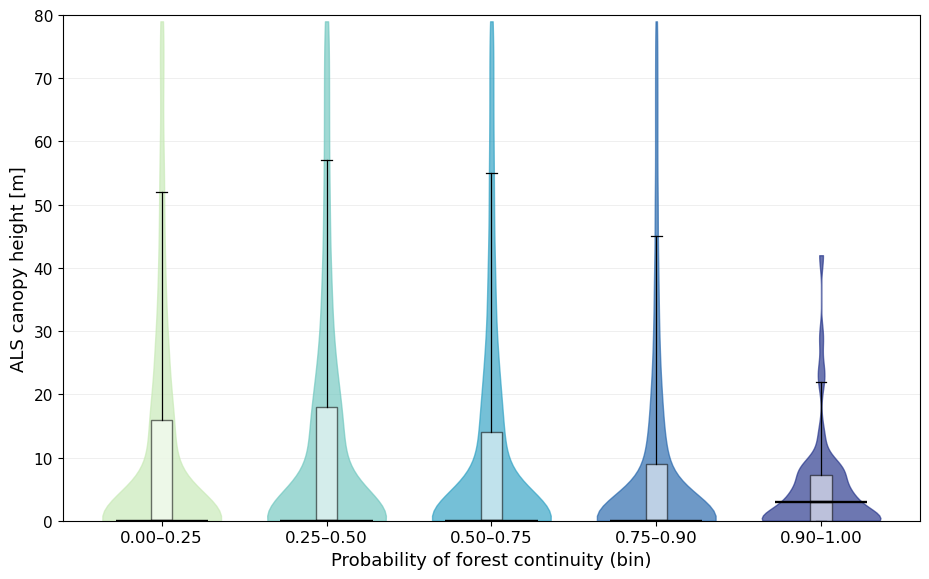

Saved: /mnt/eo/EO4Backcasting/_figures/ALS_height_probability_bins/ALS_height_by_probability_bin.png
Saved: /mnt/eo/EO4Backcasting/_figures/ALS_height_probability_bins/ALS_height_by_probability_bin.svg


In [25]:
# ------------------------------------------------------------
# Plot 1: ALS height by probability bin
# ------------------------------------------------------------

plot_data = [
    df_plot.loc[df_plot["prob_bin"] == b, "als_height"].to_numpy()
    for b in prob_order
]

positions = np.arange(1, len(prob_order) + 1)

cmap = mpl.colormaps["YlGnBu"]
colors = [cmap(x) for x in np.linspace(0.25, 0.90, len(prob_order))]

fig, ax = plt.subplots(figsize=(9.4, 5.9))

for vals, pos, color in zip(plot_data, positions, colors):
    if len(vals) == 0:
        continue

    vp = ax.violinplot(
        [vals],
        positions=[pos],
        widths=0.72,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        bw_method=0.25,
    )

    for body in vp["bodies"]:
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.65)

bp = ax.boxplot(
    plot_data,
    positions=positions,
    widths=0.13,
    showfliers=False,
    whis=(5, 95),
    patch_artist=True,
    medianprops={"linewidth": 1.7, "color": "black"},
    boxprops={"facecolor": "white", "linewidth": 1.0, "edgecolor": "black"},
    whiskerprops={"linewidth": 0.9, "color": "black"},
    capprops={"linewidth": 0.9, "color": "black"},
)

for patch in bp["boxes"]:
    patch.set_alpha(0.55)

for vals, pos in zip(plot_data, positions):
    if len(vals) == 0:
        continue

    med = np.nanmedian(vals)
    ax.hlines(
        y=med,
        xmin=pos - 0.28,
        xmax=pos + 0.28,
        colors="black",
        linewidth=1.7,
        zorder=5
    )

ax.set_xticks(positions)
ax.set_xticklabels(prob_order, fontsize=12)

ax.set_xlabel("Probability of forest continuity (bin)", fontsize=13)
ax.set_ylabel("ALS canopy height [m]", fontsize=13)
ax.tick_params(axis="y", labelsize=11)

ax.set_ylim(MIN_HEIGHT, MAX_HEIGHT)
ax.set_xlim(0.4, len(prob_order) + 0.6)

ax.grid(axis="y", linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

plt.tight_layout()

out_prob_png = fig_dir / "ALS_height_by_probability_bin.png"
out_prob_svg = fig_dir / "ALS_height_by_probability_bin.svg"

fig.savefig(out_prob_png, dpi=500, bbox_inches="tight", facecolor="white")
fig.savefig(out_prob_svg, bbox_inches="tight", facecolor="white")

plt.show()

print("Saved:", out_prob_png)
print("Saved:", out_prob_svg)

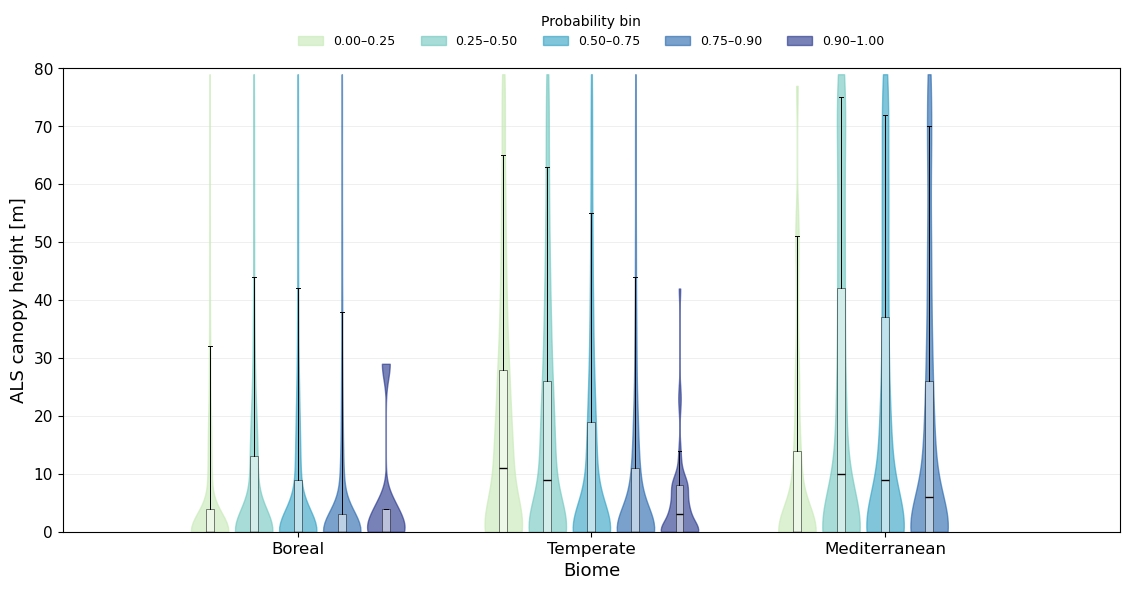

Saved: /mnt/eo/EO4Backcasting/_figures/ALS_height_probability_bins/ALS_height_by_probability_bin_and_biome.png
Saved: /mnt/eo/EO4Backcasting/_figures/ALS_height_probability_bins/ALS_height_by_probability_bin_and_biome.svg


In [26]:
# ------------------------------------------------------------
# Plot 2: ALS height by probability bin and biome
# ------------------------------------------------------------

df_biome = df_plot.dropna(subset=["biome", "prob_bin", "als_height"]).copy()

if len(df_biome) > 0:
    biome_order = (
        df_biome
        .groupby("biome")["als_height"]
        .median()
        .sort_values()
        .index
        .tolist()
    )

    n_bins = len(prob_order)
    cmap = mpl.colormaps["YlGnBu"]
    bin_colors = {
        b: cmap(x)
        for b, x in zip(prob_order, np.linspace(0.25, 0.90, n_bins))
    }

    fig, ax = plt.subplots(figsize=(11.4, 6.0))

    width = 0.75 / max(n_bins, 1)
    x_base = np.arange(len(biome_order))

    for j, prob_bin in enumerate(prob_order):
        data = [
            df_biome.loc[
                (df_biome["biome"] == biome) &
                (df_biome["prob_bin"] == prob_bin),
                "als_height"
            ].to_numpy()
            for biome in biome_order
        ]

        pos = x_base + 1 + (j - (n_bins - 1) / 2) * width

        for vals, p in zip(data, pos):
            if len(vals) == 0:
                continue

            vp = ax.violinplot(
                [vals],
                positions=[p],
                widths=width * 0.85,
                showmeans=False,
                showmedians=False,
                showextrema=False,
                bw_method=0.25,
            )

            for body in vp["bodies"]:
                body.set_facecolor(bin_colors[prob_bin])
                body.set_edgecolor(bin_colors[prob_bin])
                body.set_alpha(0.60)

        # Boxplots can become crowded; keep them narrow.
        nonempty_data = [vals if len(vals) > 0 else np.array([np.nan]) for vals in data]

        bp = ax.boxplot(
            nonempty_data,
            positions=pos,
            widths=width * 0.18,
            showfliers=False,
            whis=(5, 95),
            patch_artist=True,
            medianprops={"linewidth": 1.0, "color": "black"},
            boxprops={"facecolor": "white", "linewidth": 0.7, "edgecolor": "black"},
            whiskerprops={"linewidth": 0.7, "color": "black"},
            capprops={"linewidth": 0.7, "color": "black"},
        )

        for patch in bp["boxes"]:
            patch.set_alpha(0.50)

    ax.set_xticks(x_base + 1)
    ax.set_xticklabels(biome_order, fontsize=12)

    ax.set_xlabel("Biome", fontsize=13)
    ax.set_ylabel("ALS canopy height [m]", fontsize=13)
    ax.tick_params(axis="y", labelsize=11)

    ax.set_ylim(MIN_HEIGHT, MAX_HEIGHT)

    handles = [
        mpl.patches.Patch(
            facecolor=bin_colors[b],
            edgecolor=bin_colors[b],
            alpha=0.60,
            label=b
        )
        for b in prob_order
    ]

    ax.legend(
        handles=handles,
        title="Probability bin",
        frameon=False,
        fontsize=9,
        title_fontsize=10,
        ncol=min(len(prob_order), 5),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.14)
    )

    ax.grid(axis="y", linewidth=0.4, alpha=0.35)
    ax.set_axisbelow(True)

    plt.tight_layout()

    out_biome_png = fig_dir / "ALS_height_by_probability_bin_and_biome.png"
    out_biome_svg = fig_dir / "ALS_height_by_probability_bin_and_biome.svg"

    fig.savefig(out_biome_png, dpi=500, bbox_inches="tight", facecolor="white")
    fig.savefig(out_biome_svg, bbox_inches="tight", facecolor="white")

    plt.show()

    print("Saved:", out_biome_png)
    print("Saved:", out_biome_svg)

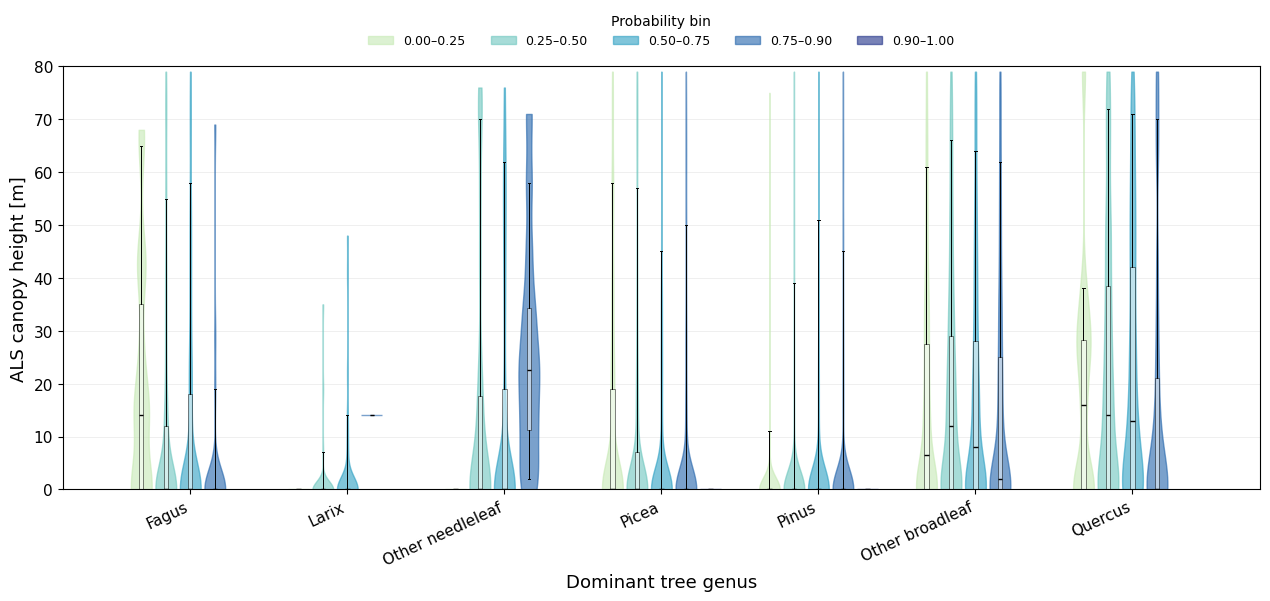

Saved: /mnt/eo/EO4Backcasting/_figures/ALS_height_probability_bins/ALS_height_by_probability_bin_and_genus.png
Saved: /mnt/eo/EO4Backcasting/_figures/ALS_height_probability_bins/ALS_height_by_probability_bin_and_genus.svg


In [11]:
# ------------------------------------------------------------
# Plot 3: ALS height by probability bin and genus
# ------------------------------------------------------------

df_genus = df_plot.dropna(subset=["genus", "prob_bin", "als_height"]).copy()
df_genus = df_genus[df_genus["genus"] != "No trees"].copy()

MIN_N_GENUS = 50

valid_genera = (
    df_genus["genus"]
    .value_counts()
    .loc[lambda x: x >= MIN_N_GENUS]
    .index
    .tolist()
)

df_genus = df_genus[df_genus["genus"].isin(valid_genera)].copy()

if len(df_genus) > 0:
    genus_order = (
        df_genus
        .groupby("genus")["als_height"]
        .median()
        .sort_values()
        .index
        .tolist()
    )

    n_bins = len(prob_order)
    cmap = mpl.colormaps["YlGnBu"]
    bin_colors = {
        b: cmap(x)
        for b, x in zip(prob_order, np.linspace(0.25, 0.90, n_bins))
    }

    fig, ax = plt.subplots(figsize=(12.8, 6.2))

    width = 0.78 / max(n_bins, 1)
    x_base = np.arange(len(genus_order))

    for j, prob_bin in enumerate(prob_order):
        data = [
            df_genus.loc[
                (df_genus["genus"] == genus) &
                (df_genus["prob_bin"] == prob_bin),
                "als_height"
            ].to_numpy()
            for genus in genus_order
        ]

        pos = x_base + 1 + (j - (n_bins - 1) / 2) * width

        for vals, p in zip(data, pos):
            if len(vals) == 0:
                continue

            vp = ax.violinplot(
                [vals],
                positions=[p],
                widths=width * 0.85,
                showmeans=False,
                showmedians=False,
                showextrema=False,
                bw_method=0.25,
            )

            for body in vp["bodies"]:
                body.set_facecolor(bin_colors[prob_bin])
                body.set_edgecolor(bin_colors[prob_bin])
                body.set_alpha(0.60)

        nonempty_data = [vals if len(vals) > 0 else np.array([np.nan]) for vals in data]

        bp = ax.boxplot(
            nonempty_data,
            positions=pos,
            widths=width * 0.18,
            showfliers=False,
            whis=(5, 95),
            patch_artist=True,
            medianprops={"linewidth": 1.0, "color": "black"},
            boxprops={"facecolor": "white", "linewidth": 0.7, "edgecolor": "black"},
            whiskerprops={"linewidth": 0.7, "color": "black"},
            capprops={"linewidth": 0.7, "color": "black"},
        )

        for patch in bp["boxes"]:
            patch.set_alpha(0.50)

    ax.set_xticks(x_base + 1)
    ax.set_xticklabels(genus_order, fontsize=11, rotation=25, ha="right")

    ax.set_xlabel("Dominant tree genus", fontsize=13)
    ax.set_ylabel("ALS canopy height [m]", fontsize=13)
    ax.tick_params(axis="y", labelsize=11)

    ax.set_ylim(MIN_HEIGHT, MAX_HEIGHT)

    handles = [
        mpl.patches.Patch(
            facecolor=bin_colors[b],
            edgecolor=bin_colors[b],
            alpha=0.60,
            label=b
        )
        for b in prob_order
    ]

    ax.legend(
        handles=handles,
        title="Probability bin",
        frameon=False,
        fontsize=9,
        title_fontsize=10,
        ncol=min(len(prob_order), 5),
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15)
    )

    ax.grid(axis="y", linewidth=0.4, alpha=0.35)
    ax.set_axisbelow(True)

    plt.tight_layout()

    out_genus_png = fig_dir / "ALS_height_by_probability_bin_and_genus.png"
    out_genus_svg = fig_dir / "ALS_height_by_probability_bin_and_genus.svg"

    fig.savefig(out_genus_png, dpi=500, bbox_inches="tight", facecolor="white")
    fig.savefig(out_genus_svg, bbox_inches="tight", facecolor="white")

    plt.show()

    print("Saved:", out_genus_png)
    print("Saved:", out_genus_svg)

In [12]:
# ------------------------------------------------------------
# Summary tables
# ------------------------------------------------------------

summary_prob = (
    df_plot
    .groupby("prob_bin")["als_height"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        q25=lambda x: np.nanquantile(x, 0.25),
        q75=lambda x: np.nanquantile(x, 0.75),
        p90=lambda x: np.nanquantile(x, 0.90),
    )
    .reset_index()
)

summary_biome = (
    df_plot
    .dropna(subset=["biome"])
    .groupby(["prob_bin", "biome"])["als_height"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        q25=lambda x: np.nanquantile(x, 0.25),
        q75=lambda x: np.nanquantile(x, 0.75),
        p90=lambda x: np.nanquantile(x, 0.90),
    )
    .reset_index()
)

summary_genus = (
    df_plot
    .dropna(subset=["genus"])
    .query("genus != 'No trees'")
    .groupby(["prob_bin", "genus"])["als_height"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        q25=lambda x: np.nanquantile(x, 0.25),
        q75=lambda x: np.nanquantile(x, 0.75),
        p90=lambda x: np.nanquantile(x, 0.90),
    )
    .reset_index()
)

summary_prob_fp = analysis_cache_dir / "ALS_height_summary_by_probability_bin.csv"
summary_biome_fp = analysis_cache_dir / "ALS_height_summary_by_probability_bin_and_biome.csv"
summary_genus_fp = analysis_cache_dir / "ALS_height_summary_by_probability_bin_and_genus.csv"

summary_prob.to_csv(summary_prob_fp, index=False)
summary_biome.to_csv(summary_biome_fp, index=False)
summary_genus.to_csv(summary_genus_fp, index=False)

display(summary_prob)
display(summary_biome)
display(summary_genus)

print("Saved:", summary_prob_fp)
print("Saved:", summary_biome_fp)
print("Saved:", summary_genus_fp)

,prob_bin,n,mean,median,q25,q75,p90
0,0.00–0.25,1105,10.377376,0.0,0.0,16.0,35.0
1,0.25–0.50,10000,11.790000,0.0,0.0,18.0,38.0
2,0.50–0.75,15016,10.673082,0.0,0.0,14.0,38.0
3,0.75–0.90,4491,7.816522,0.0,0.0,9.0,26.0
4,0.90–1.00,27,4.296296,3.0,0.0,7.5,10.2


,prob_bin,biome,n,mean,median,q25,q75,p90
0,0.00–0.25,Boreal,660,5.728788,0.0,0.0,4.5,19.0
1,0.00–0.25,Mediterranean,20,9.500000,0.0,0.0,17.0,29.8
2,0.00–0.25,Temperate,411,17.255474,11.0,0.0,26.0,50.0
3,0.25–0.50,Boreal,6135,8.465363,0.0,0.0,13.0,26.0
4,0.25–0.50,Mediterranean,466,21.364807,9.0,0.0,39.0,68.5
5,0.25–0.50,Temperate,3285,16.473364,9.0,0.0,26.0,48.0
6,0.50–0.75,Boreal,7643,7.233285,0.0,0.0,9.0,25.0
7,0.50–0.75,Mediterranean,1380,20.926087,9.0,0.0,39.5,64.0
8,0.50–0.75,Temperate,5900,12.581525,1.0,0.0,19.0,41.0
9,0.75–0.90,Boreal,1902,5.644585,0.0,0.0,4.0,21.0


,prob_bin,genus,n,mean,median,q25,q75,p90
0,0.00–0.25,Fagus,19,20.052632,14.0,0.00,35.00,48.2
1,0.00–0.25,Larix,1,0.000000,0.0,0.00,0.00,0.0
2,0.00–0.25,Other broadleaf,178,15.882022,6.5,0.00,27.50,48.6
3,0.00–0.25,Other needleleaf,2,0.000000,0.0,0.00,0.00,0.0
4,0.00–0.25,Picea,115,12.339130,0.0,0.00,19.00,44.6
5,0.00–0.25,Pinus,386,2.031088,0.0,0.00,0.00,0.0
6,0.00–0.25,Quercus,16,18.250000,16.0,0.00,28.25,36.0
7,0.25–0.50,Fagus,243,9.839506,0.0,0.00,12.00,38.8
8,0.25–0.50,Larix,40,1.525000,0.0,0.00,0.00,0.0
9,0.25–0.50,Other broadleaf,1429,18.689993,12.0,0.00,29.00,52.2


Saved: /mnt/eo/EO4Backcasting/_analysis_cache/ALS_height_summary_by_probability_bin.csv
Saved: /mnt/eo/EO4Backcasting/_analysis_cache/ALS_height_summary_by_probability_bin_and_biome.csv
Saved: /mnt/eo/EO4Backcasting/_analysis_cache/ALS_height_summary_by_probability_bin_and_genus.csv
